<a href="https://colab.research.google.com/github/JX-bio/bioprocess-analysis/blob/main/AKTA_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving home made AAV8 affinity 5mL run 010 aav6 6v3 001.csv to home made AAV8 affinity 5mL run 010 aav6 6v3 001 (1).csv


Plot saved as akta_plot_output.png


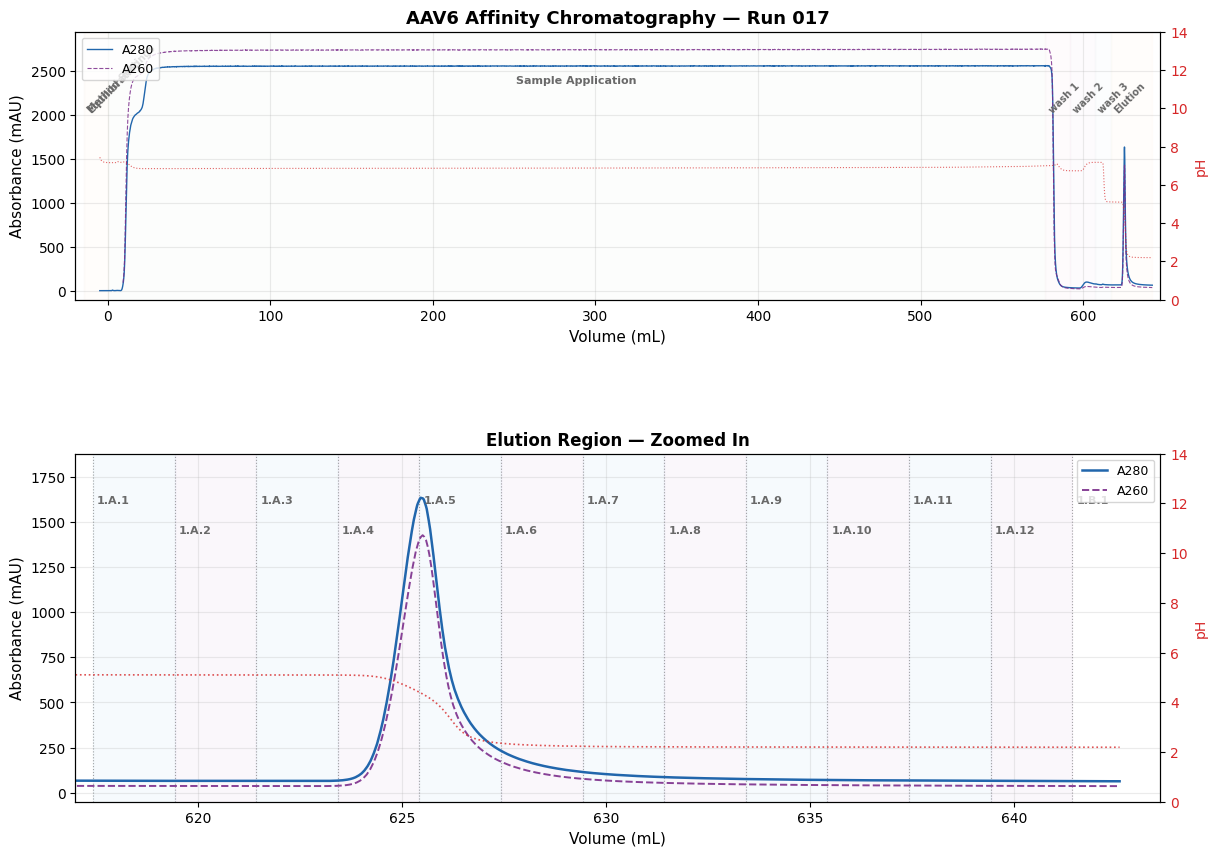

In [6]:
"""
AKTA Affinity Chromatography Plot Script
Author: Jenna Xu

How to use:
  1. Export your AKTA run from Unicorn as CSV
     - Make sure to include: UV1_280, UV2_260, pH (if available), Fractions
  2. Upload the CSV to Google Colab
  3. Change INPUT_FILE and RUN_TITLE below
  4. Run!

Output:
  - Full run overview (top panel)
  - Elution region zoomed in (bottom panel)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── SETTINGS — change these every run ─────────────────────────────────────────
INPUT_FILE  = "home made AAV8 affinity 5mL run 010 aav6 6v3 001.csv"          # your exported CSV filename
RUN_TITLE   = "AAV6 Affinity Chromatography — Run 017"   # plot title
ELUTION_START_ML = 617                     # where elution zoom starts (mL)
# ──────────────────────────────────────────────────────────────────────────────

# Colors
C280 = '#2166ac'   # blue  — A280
C260 = '#7b2d8b'   # purple — A260
C_PH = '#d62728'   # red   — pH


def load_akta_csv(filepath):
    """Read Unicorn-exported CSV (utf-16, tab-separated, 3-row header).
    Auto-detects whether pH channel is present by reading the channel row.
    """
    # Read channel names from row 1 to detect pH
    header = pd.read_csv(filepath, encoding='utf-16', sep='\t',
                         header=None, skiprows=1, nrows=1, low_memory=False)
    channels = header.iloc[0].tolist()
    has_pH = 'pH' in channels

    # Read data
    df = pd.read_csv(filepath, encoding='utf-16', sep='\t',
                     header=2, low_memory=False)

    if has_pH:
        # 16 columns: A280, A260, Ratio, pH, Injection, Logbook, Fraction, cut
        df.columns = ['vol_A280','A280','vol_A260','A260','vol_ratio','ratio',
                      'vol_pH','pH','vol_inj','injection','vol_logbook','logbook',
                      'vol_fraction','fraction','vol_cut','cut']
    else:
        # 14 columns: A280, A260, Ratio, Injection, Logbook, Fraction, cut
        df.columns = ['vol_A280','A280','vol_A260','A260','vol_ratio','ratio',
                      'vol_inj','injection','vol_logbook','logbook',
                      'vol_fraction','fraction','vol_cut','cut']

    # Convert to numeric
    for col in ['vol_A280','A280','vol_A260','A260','vol_fraction']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    if has_pH:
        df['vol_pH'] = pd.to_numeric(df['vol_pH'], errors='coerce')
        df['pH']     = pd.to_numeric(df['pH'],     errors='coerce')

    return df


def get_steps(df):
    """Extract run step boundaries from logbook."""
    log = df[['vol_logbook','logbook']].dropna()
    log = log[log['logbook'].str.strip() != '']
    log['vol_logbook'] = pd.to_numeric(log['vol_logbook'], errors='coerce')
    return log.dropna().reset_index(drop=True)


def get_fractions(df, min_vol=0):
    """Extract fraction markers."""
    frac = df[['vol_fraction','fraction']].dropna()
    frac = frac[frac['fraction'].str.strip() != '']
    frac = frac[~frac['fraction'].str.contains('Waste', na=False)]
    frac = frac[frac['vol_fraction'] >= min_vol]
    return frac.dropna().reset_index(drop=True)


def plot_run(df, title, elution_start):
    vol_max = df['vol_A280'].max()

    # UV data
    uv = df[['vol_A280','A280','vol_A260','A260']].dropna(subset=['vol_A280','A280'])
    uv = uv[(uv['vol_A280'] >= -5) & (uv['vol_A280'] <= vol_max)]
    uv_el_280 = uv[(uv['vol_A280'] >= elution_start)]
    uv_el_260 = df[['vol_A260','A260']].dropna()
    uv_el_260 = uv_el_260[(uv_el_260['vol_A260'] >= elution_start) &
                           (uv_el_260['vol_A260'] <= vol_max)]

    # pH data (optional)
    has_pH = 'pH' in df.columns
    if has_pH:
        ph_full = df[['vol_pH','pH']].dropna()
        ph_full = ph_full[(ph_full['vol_pH'] >= -5) & (ph_full['vol_pH'] <= vol_max)]
        ph_el   = ph_full[ph_full['vol_pH'] >= elution_start]

    # Steps and fractions
    steps     = get_steps(df)
    fractions = get_fractions(df, min_vol=elution_start)

    step_colors = ['#e8f4f8','#fff3e0','#e8f5e9','#fce4ec','#f3e5f5']
    step_vols   = list(steps['vol_logbook'].values) + [vol_max]
    step_names  = list(steps['logbook'].values)

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 1.3], hspace=0.5)

    # ── Top: Full run ──────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])

    if has_pH:
        ax1_ph = ax1.twinx()
        ax1_ph.plot(ph_full['vol_pH'], ph_full['pH'],
                    color=C_PH, linewidth=0.8, linestyle=':', alpha=0.7, label='pH')
        ax1_ph.set_ylabel('pH', color=C_PH, fontsize=10)
        ax1_ph.tick_params(axis='y', labelcolor=C_PH)
        ax1_ph.set_ylim(0, 14)

    for i, name in enumerate(step_names):
        ax1.axvspan(step_vols[i], step_vols[i+1],
                    alpha=0.12, color=step_colors[i % len(step_colors)])
        width = step_vols[i+1] - step_vols[i]
        mid   = (step_vols[i] + step_vols[i+1]) / 2
        ymax_label = uv['A280'].max() * 0.92
        if width > 30:
            ax1.text(mid, ymax_label, name, fontsize=8, ha='center',
                     color='dimgray', fontweight='bold')
        else:
            ax1.text(step_vols[i]+1, ymax_label * 0.85, name,
                     fontsize=7, ha='left', color='dimgray',
                     fontweight='bold', rotation=45, va='bottom')

    ax1.plot(uv['vol_A280'], uv['A280'], color=C280, linewidth=1.0, label='A280')
    ax1.plot(uv['vol_A260'], uv['A260'], color=C260, linewidth=0.8,
             linestyle='--', label='A260', alpha=0.85)

    ax1.set_xlabel('Volume (mL)', fontsize=11)
    ax1.set_ylabel('Absorbance (mAU)', fontsize=11)
    ax1.set_title(title, fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9, loc='upper left')
    ax1.grid(True, alpha=0.25)
    ax1.set_xlim(-20, vol_max + 5)
    ax1.set_ylim(-100, uv['A280'].max() * 1.15)

    # ── Bottom: Elution zoom ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])

    if has_pH:
        ax2_ph = ax2.twinx()
        ax2_ph.plot(ph_el['vol_pH'], ph_el['pH'],
                    color=C_PH, linewidth=1.2, linestyle=':', alpha=0.8, label='pH')
        ax2_ph.set_ylabel('pH', color=C_PH, fontsize=10)
        ax2_ph.tick_params(axis='y', labelcolor=C_PH)
        ax2_ph.set_ylim(0, 14)

    # Fraction shading and labels
    frac_vols   = fractions['vol_fraction'].values
    shade_colors = ['#d6eaf8','#e8daef'] * 20
    for i in range(len(frac_vols) - 1):
        ax2.axvspan(frac_vols[i], frac_vols[i+1], alpha=0.2,
                    color=shade_colors[i])
    for i, (_, row) in enumerate(fractions.iterrows()):
        ax2.axvline(x=row['vol_fraction'], color='gray',
                    linewidth=0.8, linestyle=':', alpha=0.7)
        ymax_el = max(uv_el_280['A280'].max(), uv_el_260['A260'].max())
        y_pos = ymax_el * (0.98 if i % 2 == 0 else 0.88)
        ax2.text(row['vol_fraction'] + 0.1, y_pos, row['fraction'],
                 fontsize=8, ha='left', color='dimgray', fontweight='bold')

    ax2.plot(uv_el_280['vol_A280'], uv_el_280['A280'],
             color=C280, linewidth=1.8, label='A280')
    ax2.plot(uv_el_260['vol_A260'], uv_el_260['A260'],
             color=C260, linewidth=1.4, linestyle='--', label='A260', alpha=0.9)

    ymax_el = max(uv_el_280['A280'].max(), uv_el_260['A260'].max())
    ax2.set_xlabel('Volume (mL)', fontsize=11)
    ax2.set_ylabel('Absorbance (mAU)', fontsize=11)
    ax2.set_title('Elution Region — Zoomed In', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, loc='upper right')
    ax2.grid(True, alpha=0.25)
    ax2.set_xlim(elution_start, vol_max + 1)
    ax2.set_ylim(-50, ymax_el * 1.15)

    plt.savefig('akta_plot_output.png', dpi=150, bbox_inches='tight')
    print("Plot saved as akta_plot_output.png")
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_akta_csv(INPUT_FILE)
    plot_run(df, RUN_TITLE, ELUTION_START_ML)